In [1]:
# Suppress TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import warnings
warnings.filterwarnings('ignore')

# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN+LSTM architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [2]:
# Output directory for saving models and outputs
output_dir = "cnn_lstm_attention_output"
os.makedirs(output_dir, exist_ok=True)

import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

# Dataset Selection

In [3]:
import platform
import os
import getpass

# ===== COMPREHENSIVE DATASET SELECTION =====
# Support multiple dataset sources

system = platform.system()

# Try to detect username safely
try:
    username = getpass.getuser()
except:
    username = os.getenv('USER', 'anshu')

# Define base paths to check
possible_paths = [
    f"/media/anshu/New Volume/Dataset",  # External drive
    f"/home/{username}/RAVDESS",
    f"/home/{username}/Dataset",
    f"/mnt/c/Users/{username}/Desktop/RAVDESS",
    f"C:/Users/{username}/Desktop/RAVDESS",
    f"./Dataset",
]

# Find first existing path
data_directory = None
for path in possible_paths:
    if os.path.exists(path):
        data_directory = path
        break

if data_directory is None:
    data_directory = possible_paths[0]

print("Using dataset path:", data_directory)

# Check if base path exists
if not os.path.exists(data_directory):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{data_directory}

Please update the data_directory variable manually.
""")

# Load all wav files
wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)
files = wav_files

print("Total WAV files found:", len(wav_files))

# Emotion mapping
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

WAV: 17442


In [4]:
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

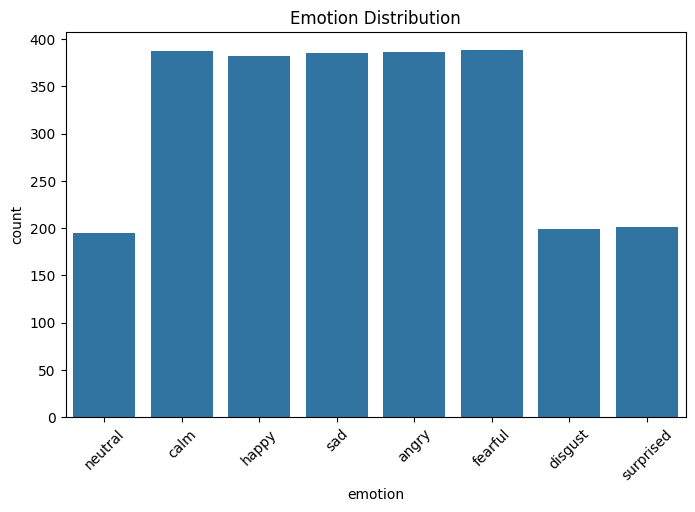

In [5]:
emotion_list = []

for file in wav_files:   
    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    emotion = emotion_map_number.get(emotion_code, "unknown")

    emotion_list.append(emotion)

# DataFrame
df = pd.DataFrame(emotion_list, columns=["emotion"])

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

# 1.2 Waveform Visualization

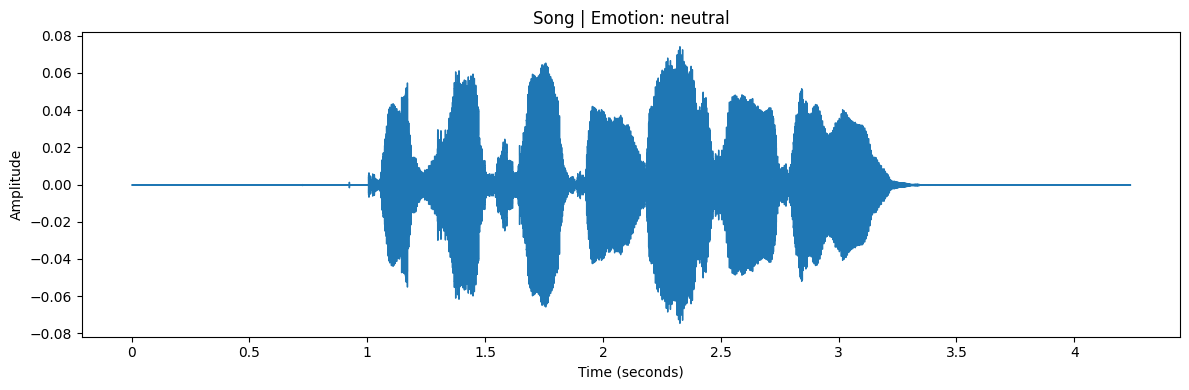

In [6]:
# ✅ Pick one file safely
file = wav_files[0]

data, sr = librosa.load(file, sr=22050)

# ---------- EXTRACT INFO ----------
file_name = os.path.basename(file)
parts = file_name.split("-")

emotion_code = parts[2] if len(parts) > 2 else "unknown"
emotion = emotion_map_number.get(emotion_code, "unknown")

dataset_type = "Speech" if "Speech" in file else "Song"

# ---------- PLOT ----------
plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr)

plt.title(f"{dataset_type} | Emotion: {emotion}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

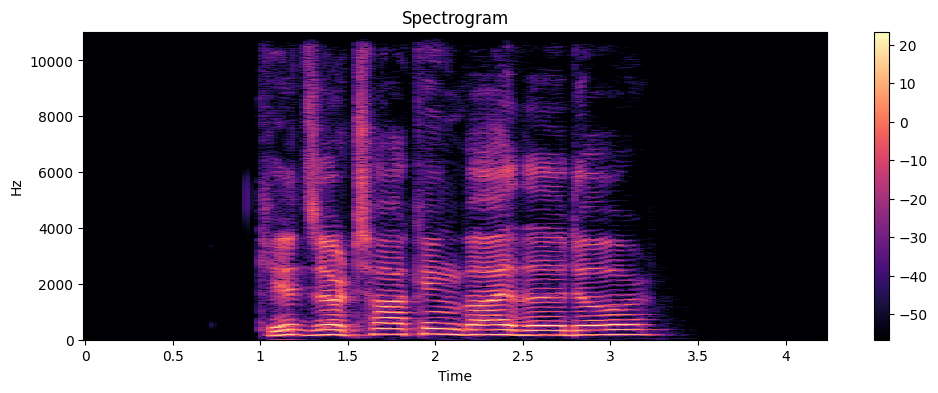

In [7]:
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")

# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

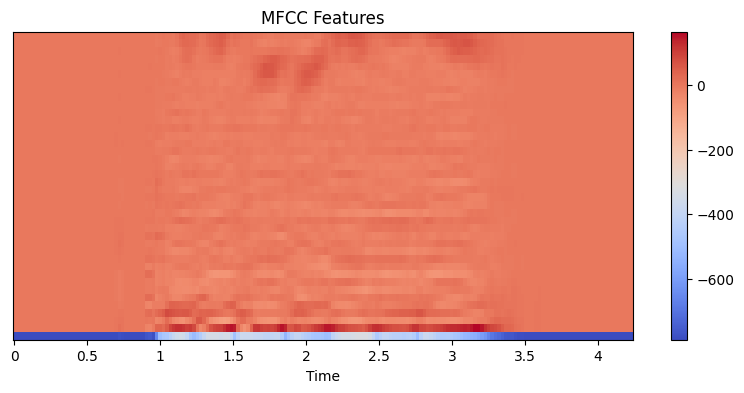

In [8]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")

# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [9]:
def extract_feature(data, sr, max_len=200):

    # ---------- EXTRACT FEATURES (NO MEAN) ----------
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # ---------- MATCH LENGTH ----------
    min_len = min(
        len(mfcc),
        len(chroma),
        len(mel),
        len(contrast),
        len(tonnetz),
        len(zcr),
        len(rms)
    )

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # ---------- CONCAT ----------
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # ---------- PAD / TRUNCATE ----------
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

# 1.5 Feature Correlation Heatmap

In [10]:
import glob
import os
import numpy as np
import librosa

sample_features = []

files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for f in files[:50]:
    try:
        data, sr = librosa.load(f, sr=22050)
        feat = extract_feature(data, sr)

        # ✅ ensure correct shape
        if feat.shape[0] == 200:
            sample_features.append(feat)
        else:
            print("Skipped (shape issue):", f)

    except Exception as e:
        print("Skipped:", f, "| Error:", e)

# ✅ convert to numpy
sample_features = np.array(sample_features)

print("Sample shape:", sample_features.shape)

Total files: 17442
Sample shape: (50, 200, 195)


# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [11]:
emotion_map = {
    'angry': 0,
    'calm': 1,
    'disgust': 2,
    'fearful': 3,
    'happy': 4,
    'neutral': 5,
    'sad': 6,
    'surprised': 7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(len(emotion_map))  # safer

    # ✅ always assign primary
    label[emotion_map[primary]] = w1 if secondary else 1.0

    # ✅ assign secondary only if exists
    if secondary:
        label[emotion_map[secondary]] = w2

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [12]:
np.random.seed(42)

In [13]:
import glob
import os
import numpy as np
import librosa
from tensorflow.keras.utils import to_categorical

X, y = [], []

# ✅ Load all files
files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for file in files:

    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        continue

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    primary_emotion = emotion_map_number.get(emotion_code, None)

    if primary_emotion is None:
        continue

    # -------- FEATURE EXTRACTION --------
    feature = extract_feature(data, sr)

    # ✅ ensure correct shape (VERY IMPORTANT)
    if feature.shape[0] != 200:
        continue

    X.append(feature)

    # ✅ one-hot label (BEST for your case)
    label = to_categorical(emotion_map[primary_emotion], num_classes=8)
    y.append(label)

# ✅ Convert to numpy
X = np.array(X)
y = np.array(y)

print("\nDataset size:", X.shape)
print("Labels shape :", y.shape)

# ✅ NORMALIZATION (VERY IMPORTANT 🔥)
mean = np.mean(X, axis=(0,1), keepdims=True)
std  = np.std(X, axis=(0,1), keepdims=True)

X = (X - mean) / (std + 1e-6)

print("Normalized X shape:", X.shape)

I0000 00:00:1775390606.429354   93095 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775390607.448442   93095 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Total files: 17442

Dataset size: (2523, 200, 195)
Labels shape : (2523, 8)
Normalized X shape: (2523, 200, 195)


# Saving the Features

In [14]:
import pickle

# ✅ save normalization values
with open(os.path.join(output_dir, "normalization.pkl"), "wb") as f:
    pickle.dump({
        "mean": mean,
        "std": std
    }, f)

# ✅ save emotion map
with open(os.path.join(output_dir, "emotion_map.pkl"), "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)

# Reshaping the Data

In [16]:
# Handle different input shapes properly
print("Original X_train shape:", X_train.shape)

if len(X_train.shape) == 2:
    # 2D data (samples, features) - add channel dimension
    X_train = np.expand_dims(X_train, axis=1)  # (samples, 1, features)
    X_test = np.expand_dims(X_test, axis=1)
elif len(X_train.shape) == 3:
    # 3D data (samples, timesteps, features) - add channel for Conv1D
    X_train = np.expand_dims(X_train, axis=-1)  # (samples, timesteps, features, 1)
    X_test = np.expand_dims(X_test, axis=-1)

print("After reshape X_train shape:", X_train.shape)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,              # 🔥 slightly higher for deep model
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # 🔥 smoother reduction
    patience=7,               # 🔥 avoid too early drop
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    os.path.join(output_dir, "best_model.keras"),      # ✅ modern format
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.layers import LSTM, Input, Bidirectional
from tensorflow.keras.layers import GlobalAveragePooling1D

model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),  # ✅ FIXED

    Conv1D(256, 5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(256, 5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64, return_sequences=True)),

    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(8, activation='softmax')
])

In [23]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0003, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',   # ✅ correct
    metrics=['accuracy']
)

model.summary()

# ✅ fix shape
X_train = np.squeeze(X_train)
X_test  = np.squeeze(X_test)

print(X_train.shape)

# ✅ train
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 200, 256)       │       249,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 200, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 100, 256)       │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 50, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 25, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 25, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           52

 Total params: 1,133,816 (4.33 MB)

 Trainable params: 1,132,536 (4.32 MB)

 Non-trainable params: 1,280 (5.00 KB)

(2018, 200, 195)
Epoch 1/1000
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1343 - loss: 2.0796
Epoch 1: val_loss improved from None to 2.02242, saving model to cnn_lstm_attention_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.1591 - loss: 2.0653 - val_accuracy: 0.2079 - val_loss: 2.0224 - learning_rate: 3.0000e-04
Epoch 2/1000
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2225 - loss: 2.0195
Epoch 2: val_loss improved from 2.02242 to 1.90712, saving model to cnn_lstm_attention_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.2195 - loss: 2.0050 - val_accuracy: 0.2911 - val_loss: 1.9071 - learning_rate: 3.0000e-04
Epoch 3/1000
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2368 - loss: 1.9679
Epoch 3: val_loss improved from 1.90712 to 1.79944, saving model to cnn_lstm_attention_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.2483 - loss: 1.9301 - val_accuracy: 0.3406 - val_

# Model Save

In [24]:
model.save(os.path.join(output_dir, "final_model_cnn_lstm.keras"))

# Evaluation Matrics

In [25]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Accuracy: 0.7564356435643564

Classification Report:

              precision    recall  f1-score   support

       angry       0.89      0.86      0.87        77
        calm       0.84      0.96      0.90        78
     disgust       0.42      0.55      0.48        40
     fearful       0.70      0.83      0.76        78
       happy       0.86      0.75      0.80        76
     neutral       0.80      0.62      0.70        39
         sad       0.80      0.57      0.67        77
   surprised       0.63      0.72      0.67        40

    accuracy                           0.76       505
   macro avg       0.74      0.73      0.73       505
weighted avg       0.77      0.76      0.76       505



# confusion matrix visual

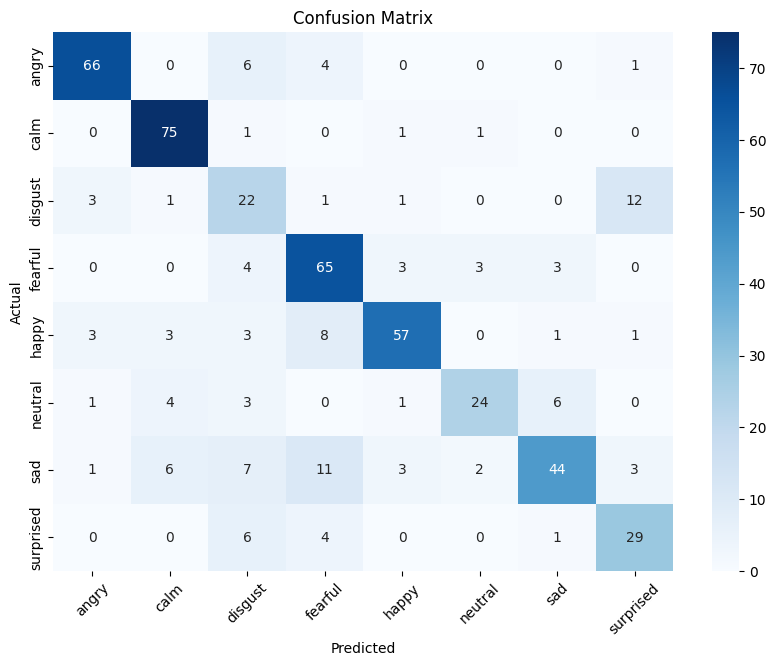

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.85714286 0.96153846 0.55       0.83333333 0.75       0.61538462
 0.57142857 0.725     ]
FPR: [0.01869159 0.03278689 0.06451613 0.06557377 0.02097902 0.01287554
 0.02570093 0.03655914]
TNR (Specificity): [0.98130841 0.96721311 0.93548387 0.93442623 0.97902098 0.98712446
 0.97429907 0.96344086]


In [30]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.7329784798534799
Mean FPR: 0.034710375672387855
Mean TNR: 0.9652896243276121


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.771285096337374
Recall: 0.7564356435643564
F1 Score: 0.7569394370759233


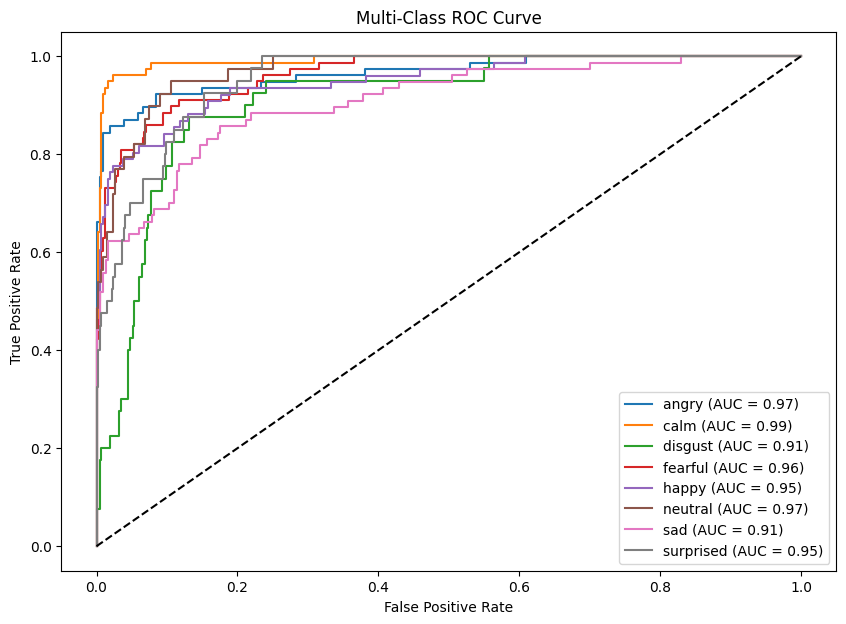

Average AUC: 0.9512776149053566


In [32]:
n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

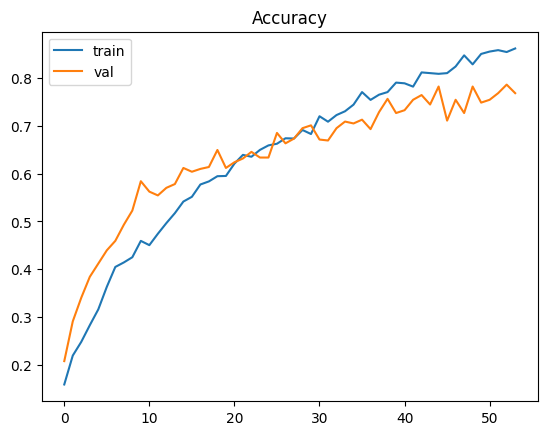

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

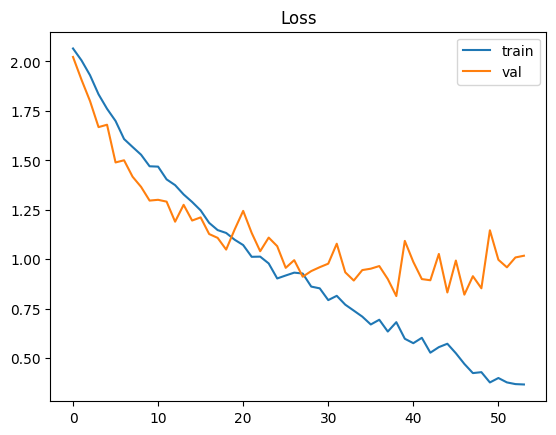

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [35]:
from tensorflow.keras.models import load_model

loaded_model = load_model(os.path.join(output_dir, "final_model_cnn_lstm.keras"))
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7564 - loss: 0.8141
Loaded model accuracy: 0.7564356327056885


### Save new audio:

# Real-Time Emotion Detection

Record audio:

In [38]:
import sounddevice as sd

def record_audio(duration=3, sr=22050, device=None):

    print("Speak now...")

    audio = sd.rec(int(duration * sr),
                   samplerate=sr,
                   channels=1,
                   device=device)

    sd.wait()

    return audio.flatten()

def extract_feature(data, sr, max_len=200):

    # ---------- EXTRACT FEATURES (NO MEAN) ----------
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # ---------- MATCH LENGTH ----------
    min_len = min(
        len(mfcc),
        len(chroma),
        len(mel),
        len(contrast),
        len(tonnetz),
        len(zcr),
        len(rms)
    )

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # ---------- CONCAT ----------
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # ---------- PAD / TRUNCATE ----------
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features


# Predict emotion:

In [43]:
import pickle

with open(os.path.join(output_dir, "normalization.pkl"), "rb") as f:
    norm = pickle.load(f)
    mean = norm["mean"]
    std = norm["std"]

with open(os.path.join(output_dir, "emotion_map.pkl"), "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

# Normalize (CORRECT WAY)
feature = (feature - mean.squeeze()) / (std.squeeze() + 1e-6)

# Add batch dimension
feature = np.expand_dims(feature, axis=0)   # (1, 200, 195)

# Predict
prediction = loaded_model.predict(feature)

# Map result
inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction[0])]

print("Emotion:", emotion)

Speak now...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
Emotion: fearful


In [ ]:
# Test on random file from dataset
import random
import librosa
import numpy as np
import os

# ===== RANDOM FILE =====
file_list = wav_files
random_file = random.choice(file_list)
print("Testing file:", random_file)

# ===== LOAD AUDIO =====
audio, sr = librosa.load(random_file, sr=22050)

# ===== GET TRUE LABEL =====
file_name = os.path.basename(random_file)
parts = file_name.split("-")

if len(parts) >= 3:
    emotion_code = parts[2]
    true_emotion = emotion_map_number.get(emotion_code, "unknown")
else:
    true_emotion = "unknown"

print("True Emotion:", true_emotion)

# ===== FEATURE EXTRACTION =====
feature = extract_feature(audio, sr)   # (200, 195)

# ===== NORMALIZATION (CORRECT WAY) =====
feature = (feature - mean.squeeze()) / (std.squeeze() + 1e-6)

# ===== RESHAPE FOR MODEL =====
feature = np.expand_dims(feature, axis=0)   # (1, 200, 195)


# Uncomment ONLY if your model input is (200,195,1)
# feature = np.expand_dims(feature, axis=-1)

# ===== PREDICTION =====
prediction = loaded_model.predict(feature)

# ===== MAP BACK =====
inv_map = {v:k for k,v in emotion_map.items()}
predicted_emotion = inv_map[np.argmax(prediction)]

print("\nPredicted Emotion:", predicted_emotion)

# ===== FULL PROBABILITIES =====
print("\nPrediction probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"{inv_map[i]}: {prob:.4f}")

Testing file: /media/anshu/New Volume/Dataset/Audio_Song_Actors_01-24/Actor_22/03-02-04-02-02-02-22.wav
True Emotion: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Predicted Emotion: sad

Prediction probabilities:
angry: 0.0000
calm: 0.0000
disgust: 0.0000
fearful: 0.0000
happy: 0.0000
neutral: 0.0000
sad: 0.9999
surprised: 0.0000
